In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.model_selection import train_test_split,cross_val_score,KFold, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder,MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,r2_score
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier, AdaBoostClassifier, VotingClassifier, StackingClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import warnings
warnings.filterwarnings('ignore')

#### INFORMATION ABOUT DATA

In [2]:
train_df = pd.read_csv("data/train.csv")
train_df.head(5)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [147]:
test_df = pd.read_csv("data/test.csv")

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [4]:
len(train_df),train_df.columns.size

(2000, 21)

In [5]:
train_df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

#### в DataFrame нет пропущенных значений.

In [6]:
train_df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [7]:
mat = train_df[['battery_power','blue','four_g','int_memory','mobile_wt','ram','touch_screen','wifi','price_range']].corr()
mat

,battery_power,blue,four_g,int_memory,mobile_wt,ram,touch_screen,wifi,price_range
battery_power,1.000000,0.011252,0.015665,-0.004004,0.001844,-0.000653,-0.010516,-0.008343,0.200723
blue,0.011252,1.000000,0.013443,0.041177,-0.008605,0.026351,0.010061,-0.021863,0.020573
four_g,0.015665,0.013443,1.000000,0.008690,-0.016537,0.007313,0.016758,-0.017620,0.014772
int_memory,-0.004004,0.041177,0.008690,1.000000,-0.034214,0.032813,-0.026999,0.006993,0.044435
mobile_wt,0.001844,-0.008605,-0.016537,-0.034214,1.000000,-0.002581,-0.014368,-0.000409,-0.030302
ram,-0.000653,0.026351,0.007313,0.032813,-0.002581,1.000000,-0.030455,0.022669,0.917046
touch_screen,-0.010516,0.010061,0.016758,-0.026999,-0.014368,-0.030455,1.000000,0.011917,-0.030411
wifi,-0.008343,-0.021863,-0.017620,0.006993,-0.000409,0.022669,0.011917,1.000000,0.018785
price_range,0.200723,0.020573,0.014772,0.044435,-0.030302,0.917046,-0.030411,0.018785,1.000000


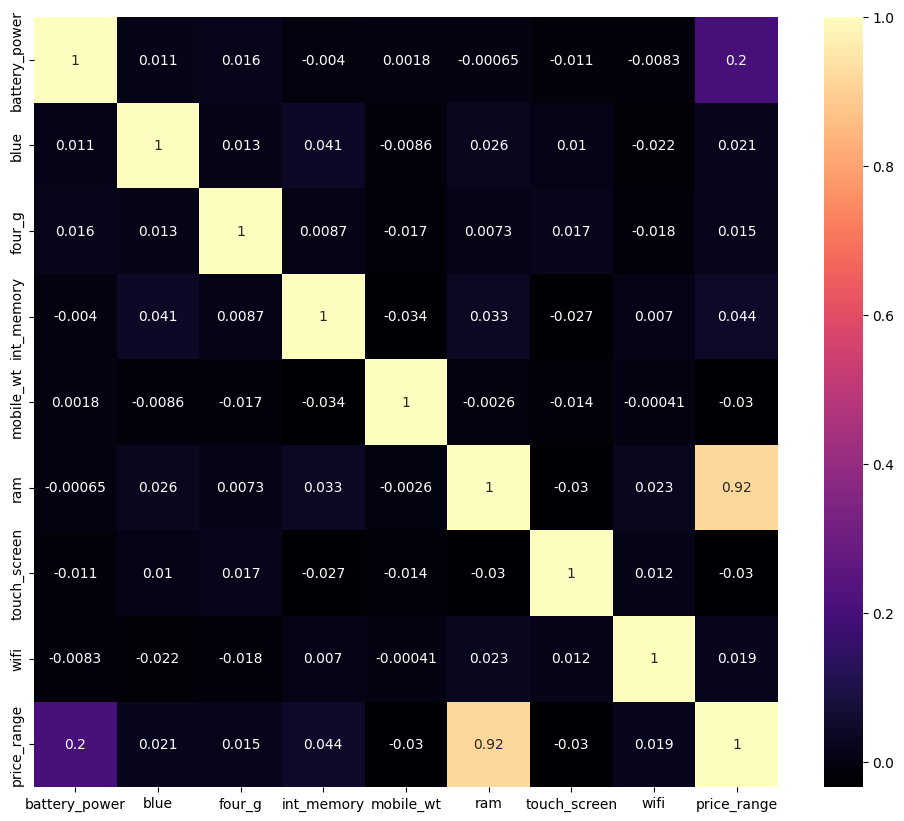

In [8]:
def built_heat_map(mat:pd.DataFrame):
    plt.figure(figsize=(12,10))
    sns.heatmap(mat,cmap='magma',annot=True)
    plt.show()
built_heat_map(mat)

In [9]:
print(train_df['price_range'].value_counts())

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


### Групировка значений

In [10]:
def find_binary_col(df:pd.DataFrame)->list:
    col = []
    for i in df.columns:
        if df[i].nunique() == 2 and df[i].dropna().isin([0, 1]).all():
            col.append(i)
    return col
find_binary_col(train_df)


['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']

In [11]:
def ax(axs,i:int,j:int,x,y,title_1:str,title_2:str,title_3:str):
    axs[i,j].bar(x, y, color='r')
    axs[i,j].set_title(title_1)
    axs[i,j].set_xlabel(title_2)
    axs[i,j].set_ylabel(title_3)

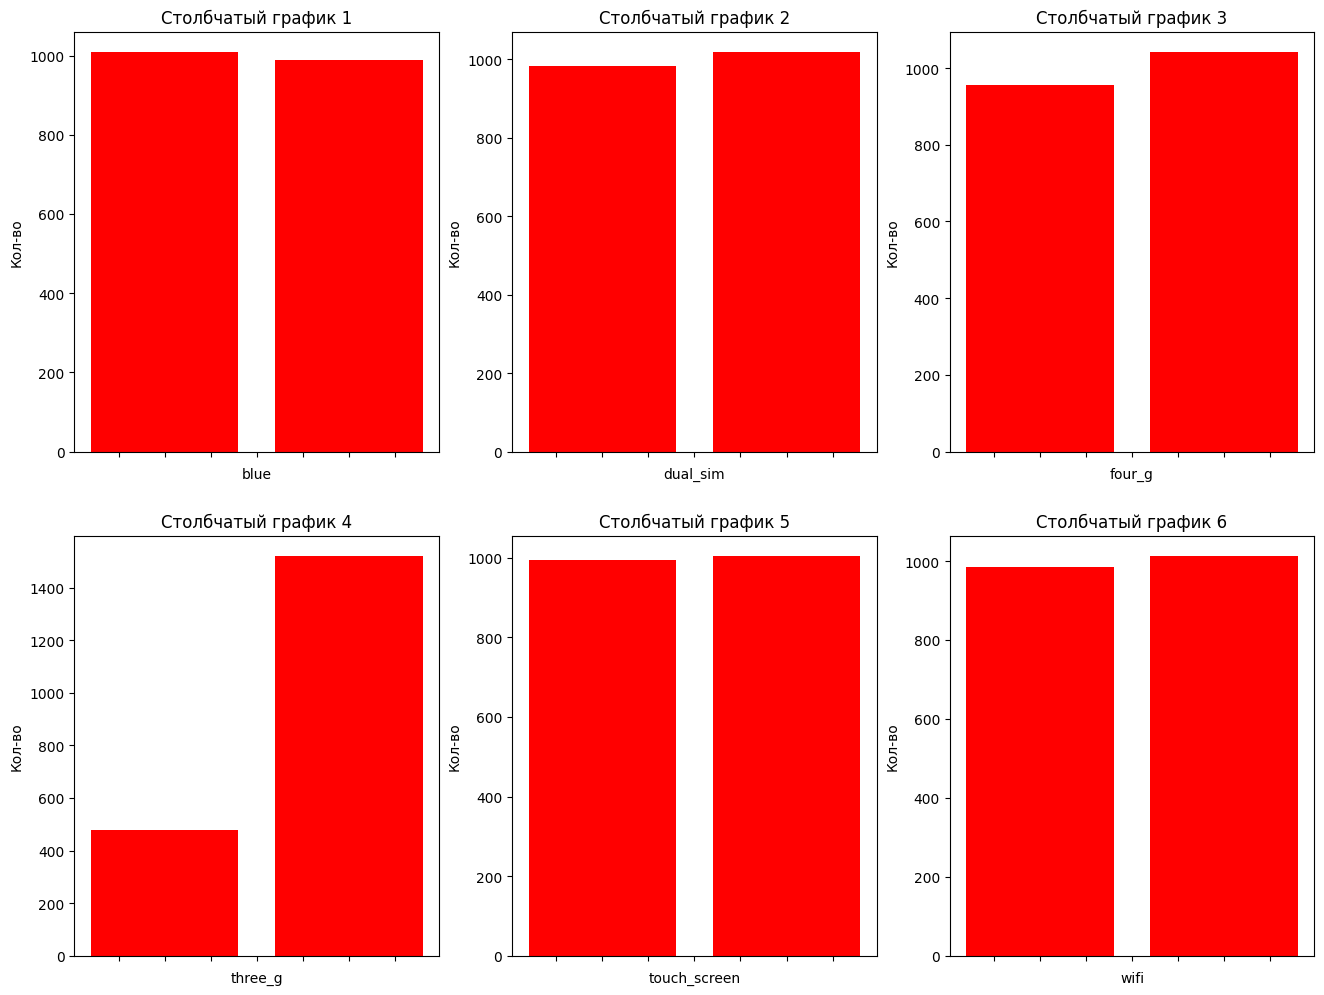

In [12]:
def plot_bar(bin_col:list):
    fig, axs = plt.subplots(2, 3, figsize=(16, 12))
    c = 0
    for i in range(2):
        for j in range(3):
            axs[i,j].bar(list(train_df['price_range'].groupby(train_df[bin_col[c]]).count().index), list(train_df['price_range'].groupby(train_df[bin_col[c]]).count()), color='r')
            axs[i,j].set_title(f'Столбчатый график {c+1}')
            axs[i,j].set_xlabel(bin_col[c])
            axs[i,j].set_ylabel('Кол-во')
            axs[i,j].set_xticklabels([], rotation=0)
            c = c + 1

            
    plt.show()
plot_bar(find_binary_col(train_df))


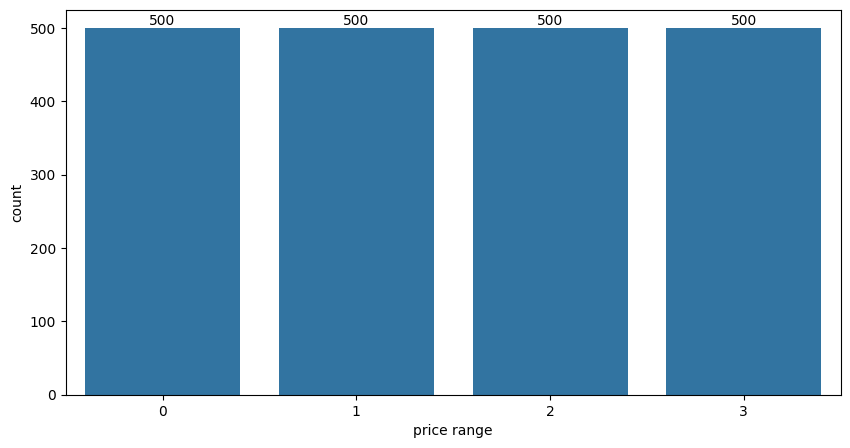

In [13]:
plt.figure(figsize=(10,5))
plt.xlabel('price range')
plt.ylabel('count')
ax=sns.countplot(x='price_range',data=train_df)
for i in ax.containers:
  ax.bar_label(i)
plt.show()

In [14]:
numeric_cols = [col for col in train_df.columns if col not in find_binary_col(train_df) and col!='price_range']
numeric_cols

['battery_power',
 'clock_speed',
 'fc',
 'int_memory',
 'm_dep',
 'mobile_wt',
 'n_cores',
 'pc',
 'px_height',
 'px_width',
 'ram',
 'sc_h',
 'sc_w',
 'talk_time']

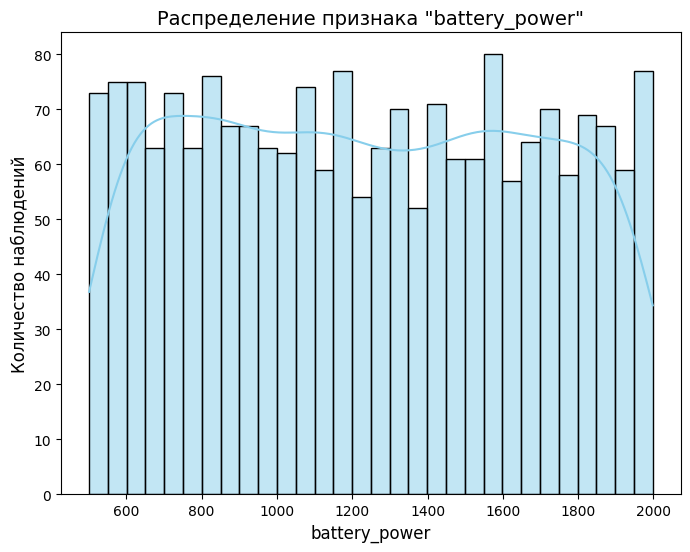

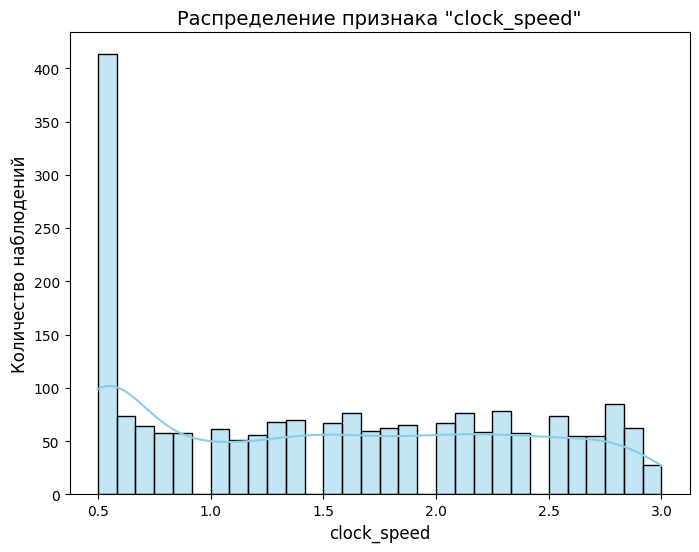

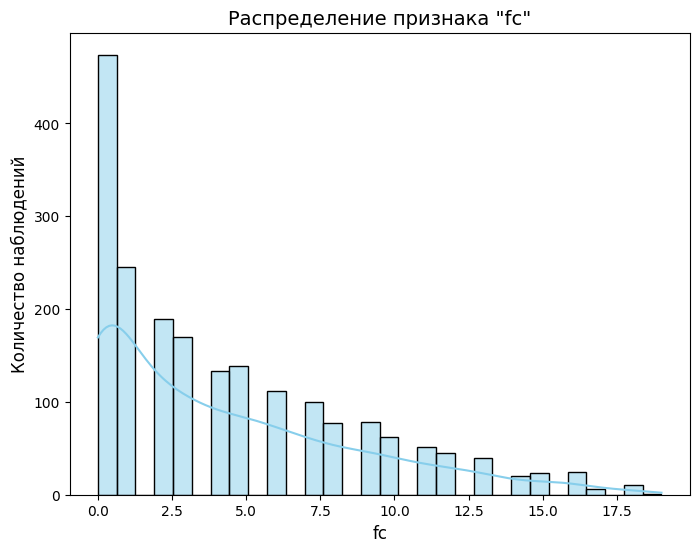

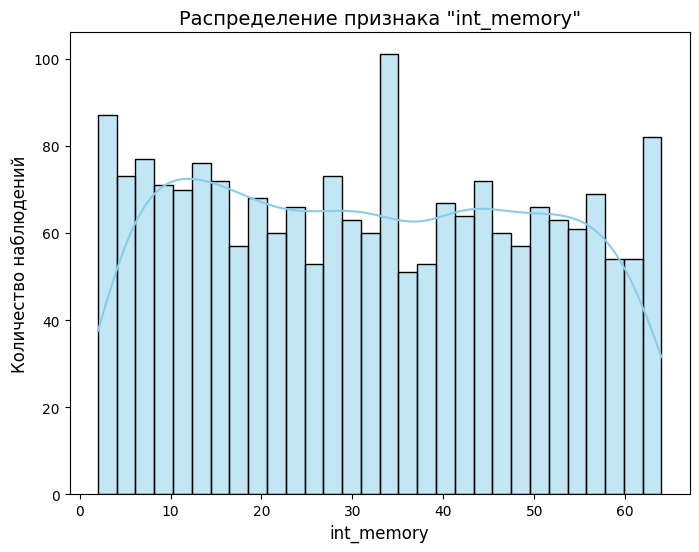

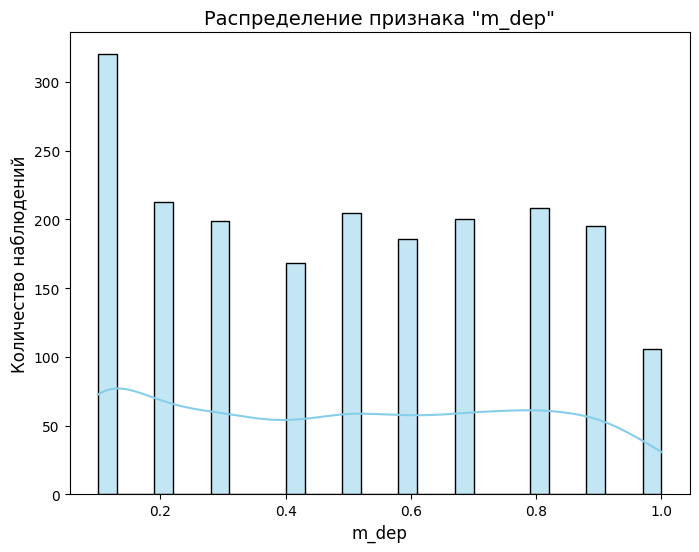

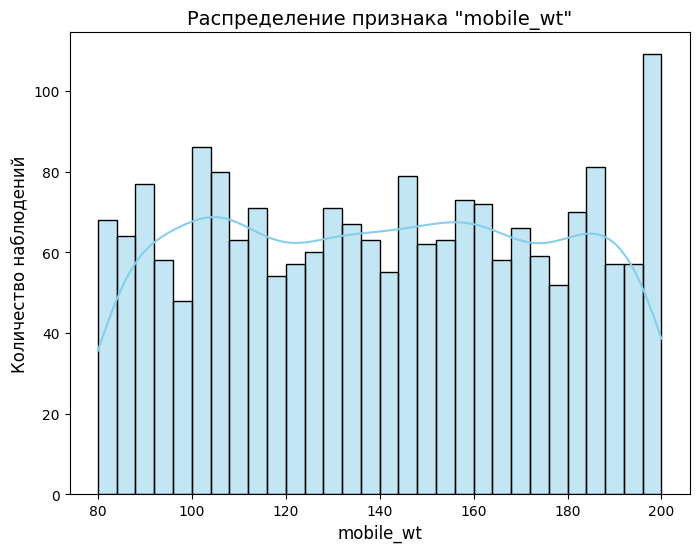

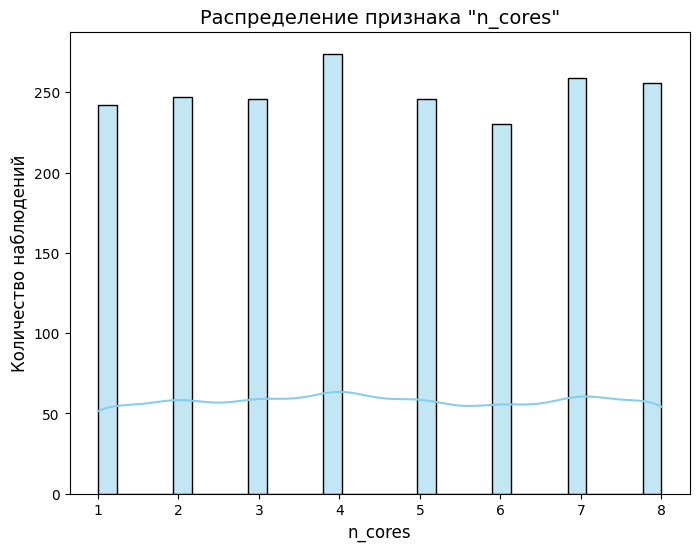

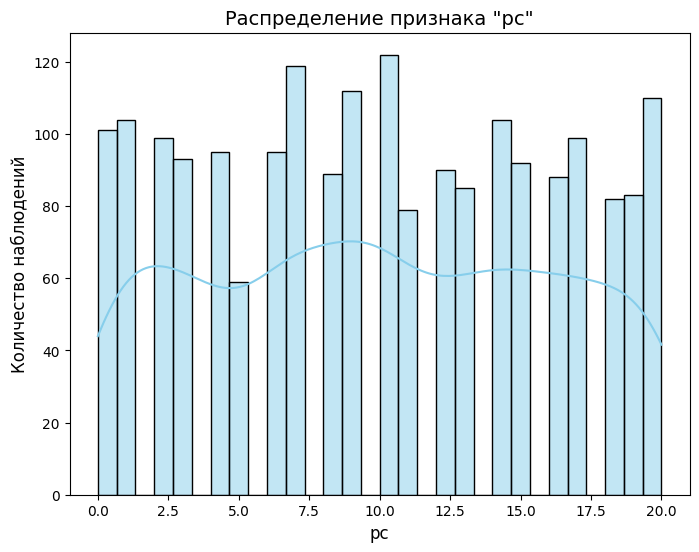

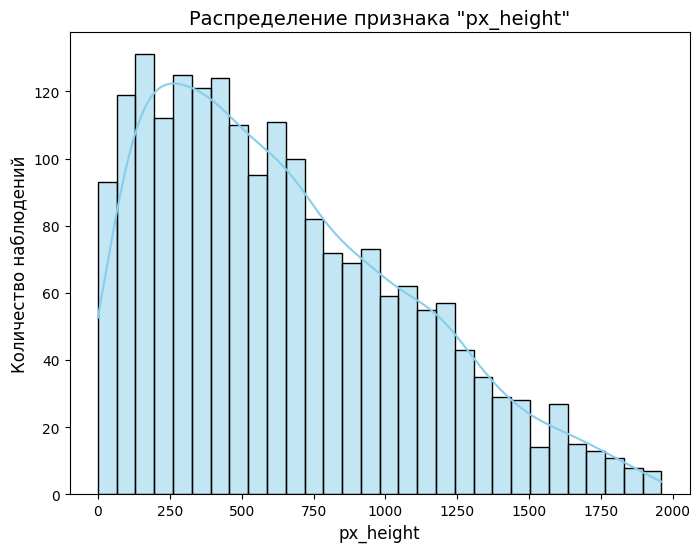

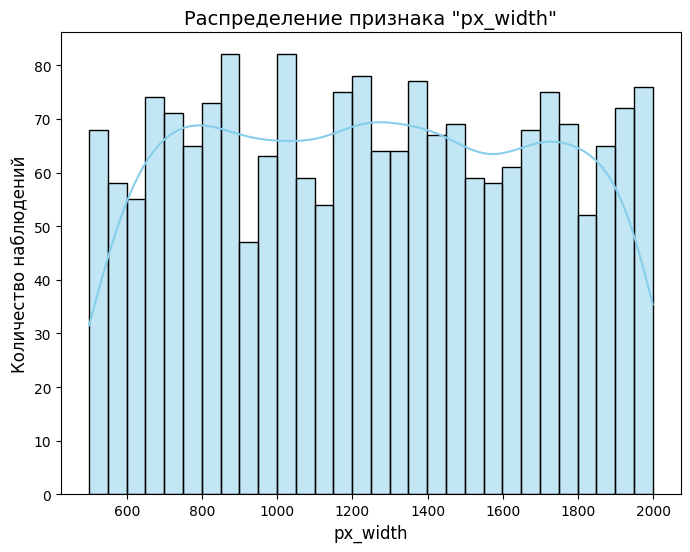

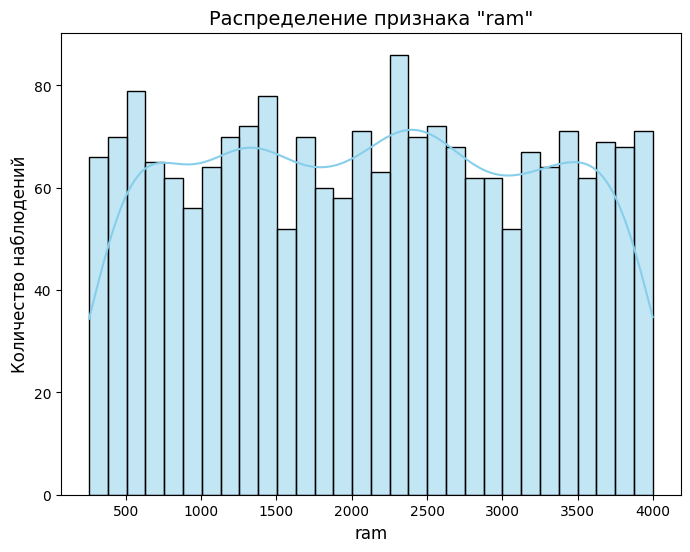

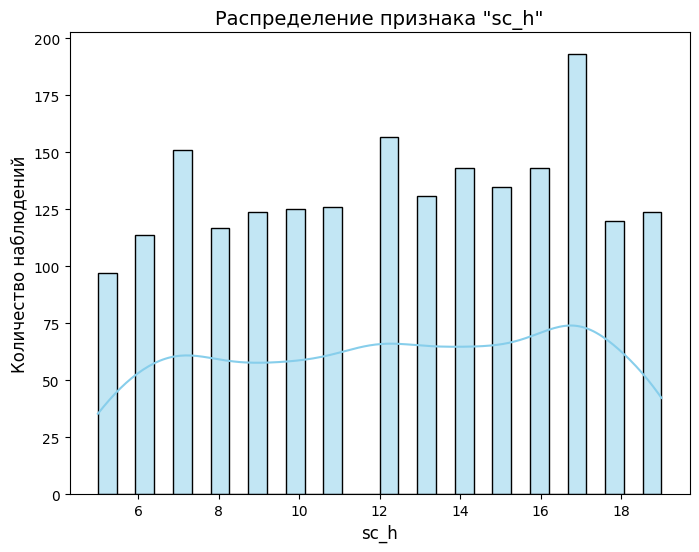

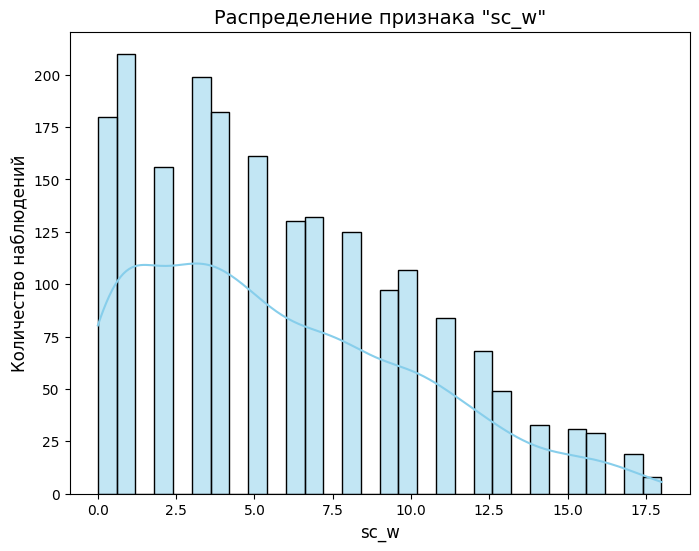

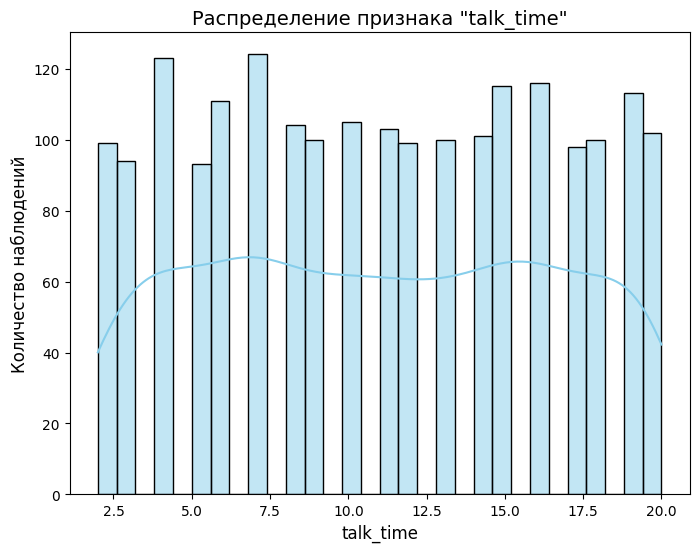

In [15]:
binary_columns = find_binary_col(train_df)

numeric_cols = [
    col for col in train_df.columns 
    if col not in binary_columns and col != 'price_range'
]

for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    

    sns.histplot(
        data=train_df, x=col, kde=True, color="skyblue",
        bins=30  
    )
    

    plt.title(f'Распределение признака "{col}"', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Количество наблюдений', fontsize=12)
    

    plt.show()

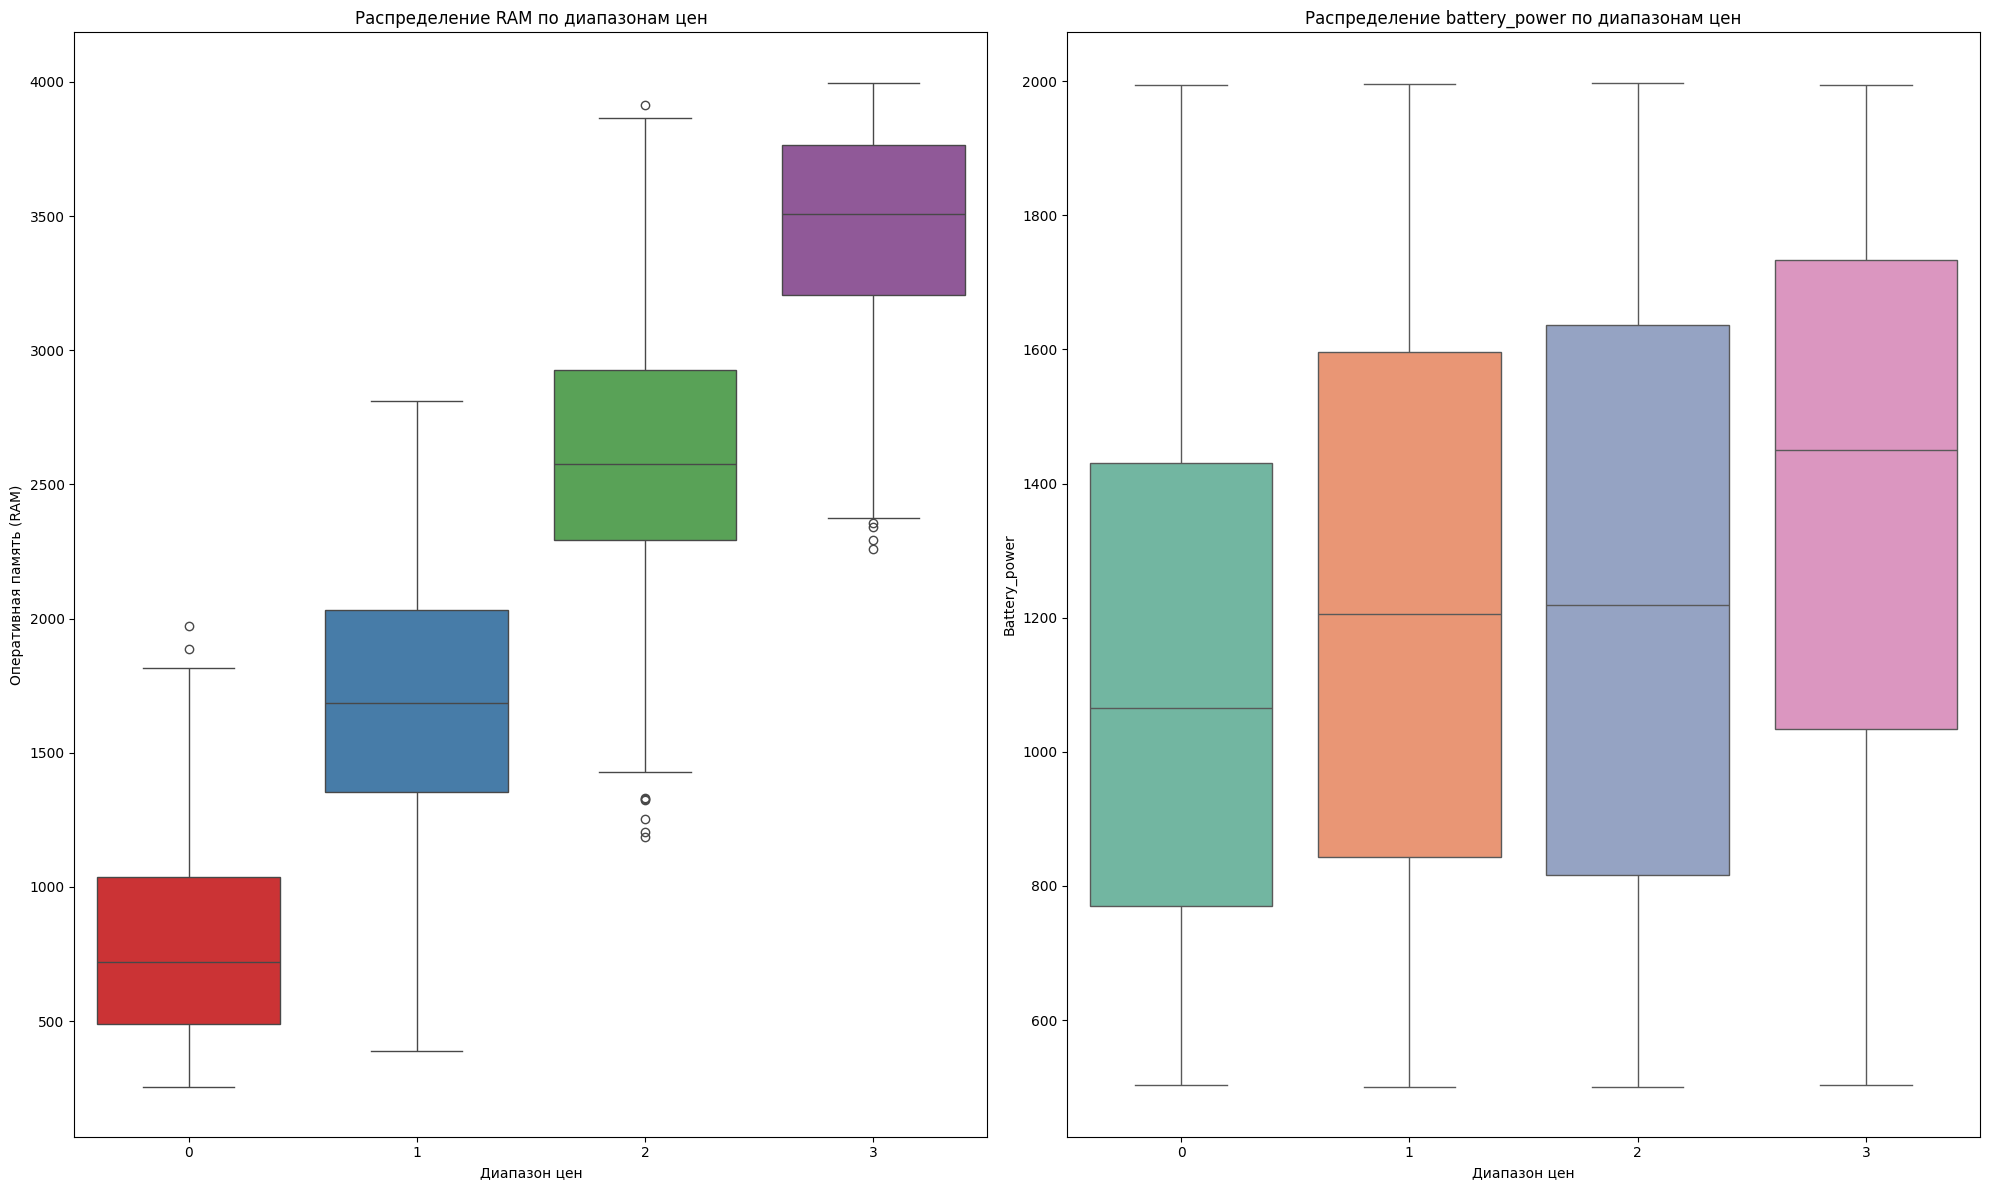

In [16]:
def create_box_plot(train_df):
    fig, axs = plt.subplots(1, 2, figsize=(20, 12))
    
    sns.boxplot(x='price_range', y='ram', data=train_df, ax=axs[0], palette='Set1')
    axs[0].set_title('Распределение RAM по диапазонам цен')
    axs[0].set_xlabel('Диапазон цен')
    axs[0].set_ylabel('Оперативная память (RAM)')

    sns.boxplot(x='price_range', y='battery_power', data=train_df, ax=axs[1], palette='Set2')
    axs[1].set_title('Распределение battery_power по диапазонам цен')
    axs[1].set_xlabel('Диапазон цен')
    axs[1].set_ylabel('Battery_power')

    plt.tight_layout()
    plt.show()
create_box_plot(train_df)

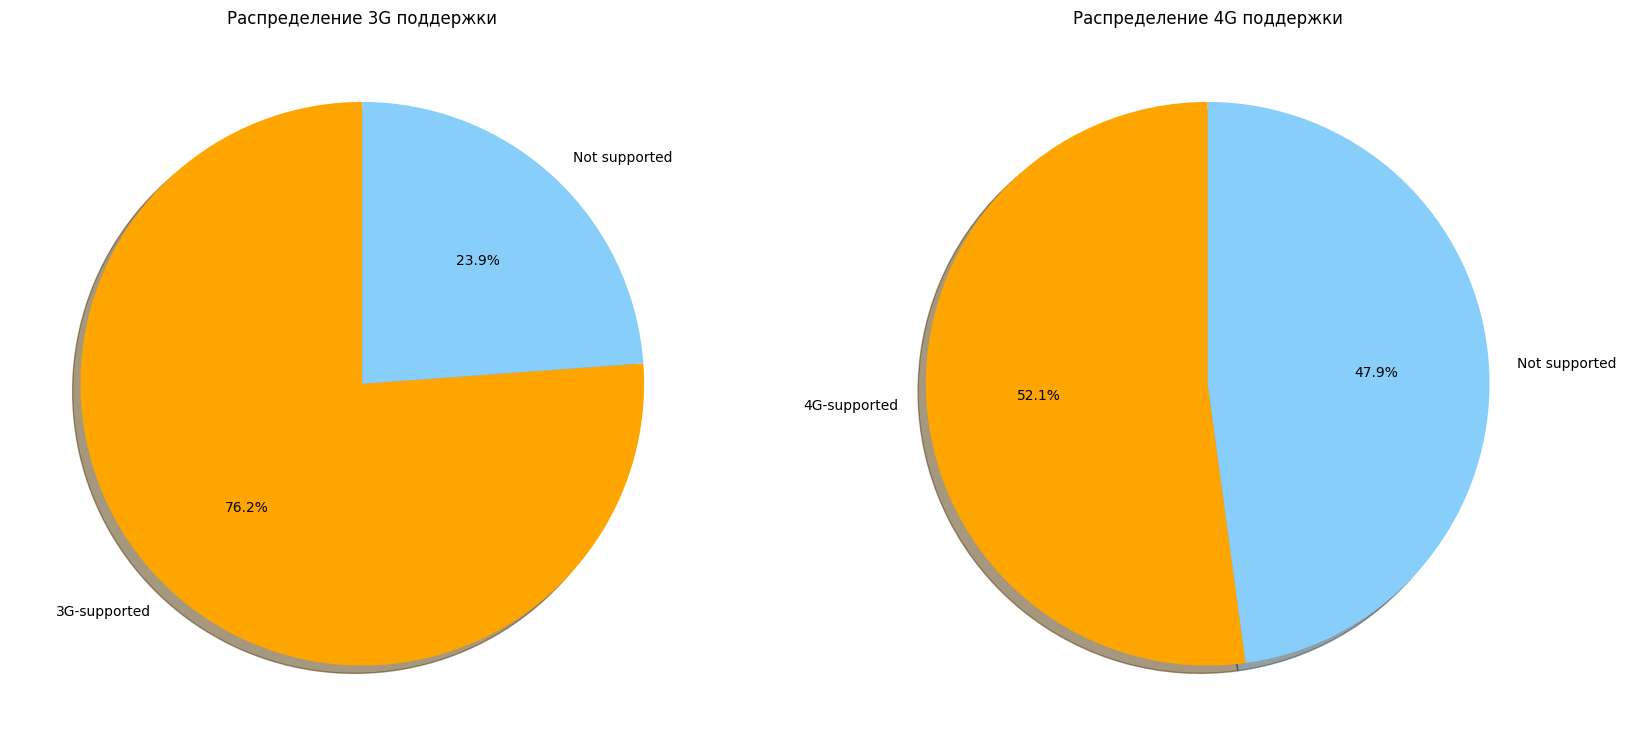

In [17]:
def create_pie(train_df, labels1,labels2):
    fig, axs = plt.subplots(1, 2, figsize=(20, 12))
    values1 = train_df['three_g'].value_counts().values
    values2 = train_df['four_g'].value_counts().values
    colors = ['orange', 'lightskyblue']
    axs[0].pie(values1, labels=labels1, autopct='%1.1f%%', shadow=True, startangle=90, colors=colors)
    axs[0].set_title('Распределение 3G поддержки')
    axs[1].pie(values2, labels=labels2, autopct='%1.1f%%', shadow=True, startangle=90, colors=colors)
    axs[1].set_title('Распределение 4G поддержки')
    plt.show()


labels1 = ["3G-supported", 'Not supported']
labels2 = ["4G-supported", 'Not supported']
create_pie(train_df, labels1,labels2)

#### Feature Engineering

In [18]:
train_df['screen_area']  = train_df['sc_h'] * train_df['sc_w']
train_df['aspect_ratio'] = train_df['sc_h'] / train_df['sc_w'].replace(0, np.nan)
train_df['px_area']= train_df['px_height'] * train_df['px_width']
train_df['ppi'] = np.sqrt(train_df['px_height']**2 + train_df['px_width']**2) / np.sqrt(train_df['sc_h']**2 + train_df['sc_w']**2)
train_df['max_gen'] = np.select([(train_df['four_g']==1), (train_df['three_g']==1)], [2, 1], default=0).astype(int)

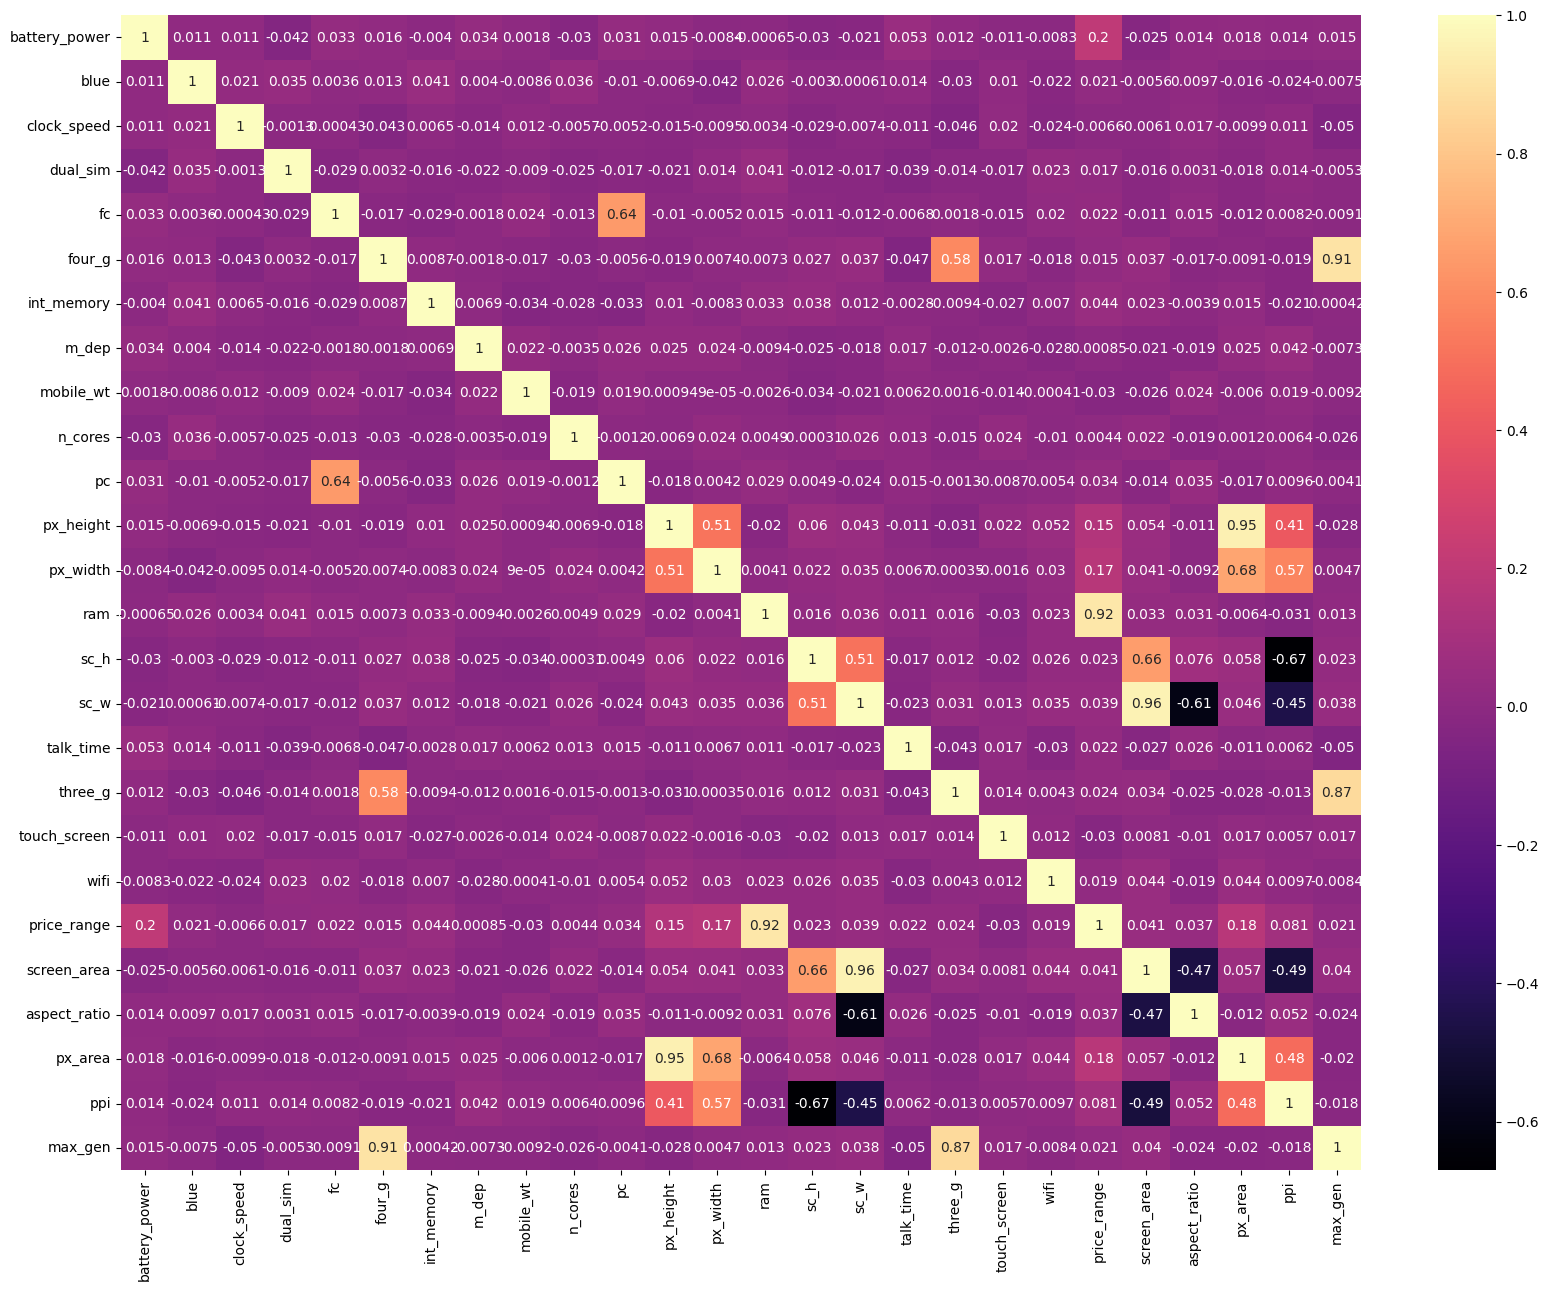

In [19]:
def built_heat_map_again(mat):
    corr=mat.corr()
    plt.figure(figsize=(20,15))
    sns.heatmap(corr,annot=True,cmap='magma')
    plt.show()
built_heat_map_again(train_df)

#### SPLIT DATA

In [20]:
x=train_df.drop(columns=['price_range','aspect_ratio'],axis=1)
y=train_df['price_range']
x.shape,y.shape

((2000, 24), (2000,))

In [21]:
y.value_counts()

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64

In [22]:
X_train,x_test,Y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=21,stratify=y,shuffle=True)

In [23]:
X_train.shape,x_test.shape

((1600, 24), (400, 24))

In [24]:
scaler = StandardScaler()
scaler

StandardScaler()

In [25]:
X_train_sc = scaler.fit_transform(X_train)
x_test_sc = scaler.transform(x_test)
X_train_sc

array([[-0.33369251, -0.97774752, -1.26780832, ...,  1.16253359,
         0.55419264,  0.87544882],
       [ 1.24546659,  1.02275892, -1.26780832, ..., -0.48404628,
        -0.33939014,  0.87544882],
       [-0.98353351, -0.97774752, -1.26780832, ..., -0.53459271,
        -1.04824098, -1.55424435],
       ...,
       [ 0.20481211, -0.97774752, -0.52766238, ...,  1.09613614,
         1.04376892, -0.33939777],
       [ 0.41839621,  1.02275892,  1.69277545, ..., -0.83609301,
        -0.55389886, -0.33939777],
       [-1.52203813,  1.02275892, -1.26780832, ...,  2.00340537,
         0.2037583 , -1.55424435]])

#### Логистическая регрессия

In [122]:
logr_st = LogisticRegression()
logr_st.fit(X_train_sc,Y_train)
logr_st.score(X_train_sc, Y_train),logr_st.score(x_test_sc, y_test) ### R^2


(0.973125, 0.975)

In [125]:
y_predict_logr_1=logr_st.predict(x_test_sc)
accuracy_score(y_test,y_predict_logr_1)

0.975

In [126]:
report=classification_report(y_test,y_predict_logr_1)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       100
           1       0.96      0.96      0.96       100
           2       0.95      0.97      0.96       100
           3       0.99      0.99      0.99       100

    accuracy                           0.97       400
   macro avg       0.98      0.98      0.98       400
weighted avg       0.98      0.97      0.98       400



In [127]:
skfold = StratifiedKFold(n_splits=10,shuffle=True,random_state=21)
skfold

StratifiedKFold(n_splits=10, random_state=21, shuffle=True)

In [128]:
sc = cross_val_score(logr_st,X_train_sc,Y_train,cv=skfold)
print(np.mean(sc))

0.9506249999999999


GridSearch

In [129]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  
    'penalty': ['l1', 'l2'],               
    'solver': ['liblinear', 'saga'],
    'class_weight':[None,'balanced']
}

In [32]:
grid=GridSearchCV(LogisticRegression(max_iter=1000),param_grid,cv=skfold,scoring='accuracy')
grid.fit(X_train,Y_train)


GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=21, shuffle=True),
             estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy')

In [33]:
grid.best_params_

{'C': 10, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}

In [130]:
best_model_lor = LogisticRegression(
    C=100,
    class_weight='balanced',
    penalty='l1',
    solver='liblinear',
    max_iter=1000
)
best_model_lor.fit(X_train_sc, Y_train)
y_pred_best_lor_2 = best_model_lor.predict(x_test_sc)
accuracy = accuracy_score(y_test, y_pred_best_lor_2)
print("Accuracy:", accuracy)
print("R^2 : ",r2_score(y_test, y_pred_best_lor_2))
print(classification_report(y_test, y_pred_best_lor_2))


Accuracy: 0.86
R^2 :  0.888
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       100
           1       0.73      0.73      0.73       100
           2       0.73      0.75      0.74       100
           3       0.99      0.99      0.99       100

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400



##### SVC

In [35]:
svc_model = SVC()
svc_model

SVC()

In [36]:
svc_model.fit(X_train_sc,Y_train)
svc_model.score(X_train_sc, Y_train),svc_model.score(x_test_sc, y_test)

(0.983125, 0.895)

In [131]:
y_predict_svc_3=svc_model.predict(x_test_sc)
accuracy_score(y_test,y_predict_svc_3)

0.895

In [132]:
report=classification_report(y_test,y_predict_svc_3)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.94      0.96       100
           1       0.83      0.90      0.87       100
           2       0.82      0.84      0.83       100
           3       0.96      0.90      0.93       100

    accuracy                           0.90       400
   macro avg       0.90      0.89      0.90       400
weighted avg       0.90      0.90      0.90       400



In [39]:
sc = cross_val_score(svc_model,X_train_sc,Y_train,cv=skfold)
print(np.mean(sc))

0.8525


In [40]:
param_grid={
    'C':[0.001,0.01,0.1,1,10],
    'kernel':['linear','poly','rbf','sigmoid'],
    'gamma':['scale','auto']
}

In [41]:
#grid=GridSearchCV(SVC(),param_grid,cv=skfold,scoring='accuracy')
#grid.fit(X_train,Y_train)

Так модель долго обучается

In [42]:
inner_cv=StratifiedKFold(n_splits=4,shuffle=True,random_state=42)
outer_cv=StratifiedKFold(n_splits=4,shuffle=True,random_state=42)

In [43]:
grid=GridSearchCV(SVC(),param_grid,cv=inner_cv,scoring='accuracy')
grid.fit(X_train_sc,Y_train)
grid.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

In [44]:
sc_out = cross_val_score(svc_model,X_train_sc,Y_train,cv=outer_cv,scoring='accuracy')
print(np.mean(sc_out))

0.845625


In [45]:
best_model_svc=SVC(C=10,gamma='scale',kernel='linear')
best_model_svc.fit(X_train_sc,Y_train)

SVC(C=10, kernel='linear')

In [133]:
y_pr_svc_4 = best_model_svc.predict(x_test_sc)
report=classification_report(y_test,y_pr_svc_4)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       100
           1       0.95      0.93      0.94       100
           2       0.92      0.96      0.94       100
           3       0.99      0.99      0.99       100

    accuracy                           0.96       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.96      0.97       400



In [134]:
accuracy = accuracy_score(y_test, y_pr_svc_4)
print("Accuracy:", accuracy)
print("R^2 : ",r2_score(y_test, y_pr_svc_4))

Accuracy: 0.965
R^2 :  0.972


##### Decesion tree

In [48]:



dec = DecisionTreeClassifier()
dec

DecisionTreeClassifier()

In [49]:
dec.fit(X_train_sc,Y_train)
dec

DecisionTreeClassifier()

In [50]:
dec.score(X_train_sc,Y_train)

1.0

In [135]:
y_pr_dec_5 = dec.predict(x_test_sc)
accuracy_score(y_pr_dec_5,y_test)

0.85

In [136]:
report=classification_report(y_test,y_pr_dec_5)
print(report)

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       100
           1       0.83      0.77      0.80       100
           2       0.76      0.83      0.79       100
           3       0.91      0.88      0.89       100

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



In [53]:
skf=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)

In [54]:
scores = cross_val_score(
    dec,
    X_train,
    Y_train,
    cv=skf,
    scoring='accuracy'
)
np.mean(scores)

np.float64(0.8487499999999999)

In [55]:
param_grid=param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}
grid_tree = GridSearchCV(dec,param_grid=param_grid,scoring='accuracy',cv=skf)
grid_tree.fit(X_train,Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 5, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [56]:
grid_tree.best_params_

{'criterion': 'entropy',
 'max_depth': 30,
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [57]:
tree_best = DecisionTreeClassifier(criterion='entropy',max_depth=10,min_samples_leaf=1,min_samples_split=2)
tree_best.fit(X_train,Y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=10)

In [139]:
y_pr_dec_6 = tree_best.predict(x_test)
report=classification_report(y_test,y_pr_dec_6)
print(report)


              precision    recall  f1-score   support

           0       0.96      0.95      0.95       100
           1       0.84      0.87      0.86       100
           2       0.78      0.85      0.81       100
           3       0.96      0.85      0.90       100

    accuracy                           0.88       400
   macro avg       0.88      0.88      0.88       400
weighted avg       0.88      0.88      0.88       400



In [140]:
accuracy = accuracy_score(y_test, y_pr_dec_6)
print("Accuracy:", accuracy)

Accuracy: 0.88


In [79]:
ran_model = RandomForestClassifier()
ran_model

RandomForestClassifier()

In [141]:
ran_model.fit(X_train,Y_train)
ran_model.score(X_train,Y_train)
y_pr_ran_7= ran_model.predict(x_test)
report=classification_report(y_test,y_pr_ran_7)
print(report)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       100
           1       0.87      0.80      0.83       100
           2       0.83      0.87      0.85       100
           3       0.96      0.94      0.95       100

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.89       400
weighted avg       0.90      0.90      0.89       400



In [142]:
skfold=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
r = cross_val_score(ran_model,X_train_sc,Y_train,cv=skfold)
print(np.mean(r))


0.8637500000000001


In [70]:
param_grid={
'n_estimators': [100, 200,300],
    'max_depth': [10,20,30],
    'min_samples_split': [2,3,5],
    'min_samples_leaf': [1,3,5]
}
gr_ran = GridSearchCV(RandomForestClassifier(),param_grid,scoring='accuracy',cv=skfold)
gr_ran.fit(X_train_sc,Y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=10, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(),
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_leaf': [1, 3, 5],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [71]:
gr_ran.best_params_

{'max_depth': 30,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 200}

In [143]:
rf_best = RandomForestClassifier(
  n_estimators=200,
  max_depth=30,
  min_samples_split=5,
  min_samples_leaf=1,
  random_state=42
  )
rf_best.fit(X_train, Y_train)
y_pr_ran_8 = rf_best.predict(x_test)
report=classification_report(y_test,y_pr_ran_8)
print(report)



              precision    recall  f1-score   support

           0       0.95      0.98      0.97       100
           1       0.91      0.86      0.89       100
           2       0.85      0.91      0.88       100
           3       0.97      0.93      0.95       100

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400



In [85]:
pickle.dump(best_model_lor,open('best_model_lor.pkl','wb'))
pickle.dump(best_model_svc,open('best_model_svc.pkl','wb'))
pickle.dump(tree_best,open('best_tree.pkl','wb'))
pickle.dump(rf_best,open('best_rf.pkl','wb'))

In [87]:
stacking_model = StackingClassifiestack_model = StackingClassifier(
    estimators=[
        ('lr', best_model_lor),
        ('rf',rf_best ),
        ('xgb', tree_best)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)
stacking_model.fit(X_train,Y_train)

StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(C=100,
                                                   class_weight='balanced',
                                                   max_iter=1000, penalty='l1',
                                                   solver='liblinear')),
                               ('rf',
                                RandomForestClassifier(max_depth=30,
                                                       min_samples_split=5,
                                                       n_estimators=200,
                                                       random_state=42)),
                               ('xgb',
                                DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=10))],
                   final_estimator=LogisticRegression(max_iter=1000),
                   n_jobs=-1)

In [144]:
y_pred_stack_1 = stacking_model.predict(x_test)
accuracy_score(y_test,y_pred_stack_1)

0.95

#### Pipeline

In [93]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder


ordinal_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [94]:
ohe_pipeline = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('one-hot', OneHotEncoder(handle_unknown = 'ignore', sparse_output=False))
])

In [114]:
base_model = {
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),

}
param_grid = [
    {'Logistic Regression' : 
        {'C' : [0.0001, 0.001, 0.1, 1, 10, 100],'penalty': ['l1', 'l2'],               
    'solver': ['liblinear', 'saga'],
    'class_weight':[None,'balanced']}
    },
    {
        'K-Nearest Neighbors' :
        {
        'n_neighbors': [3, 5, 7, 9, 11],
        'weights': ['uniform', 'distance'],
        'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
        'p': [1, 2]  # Minkowski
        }
    }
]

In [115]:
CV_lr = GridSearchCV(estimator=base_model['Logistic Regression'], param_grid=param_grid[0]['Logistic Regression'], cv=StratifiedKFold(n_splits=5))

In [145]:

from sklearn.pipeline import make_pipeline

pipefinallr = make_pipeline(StandardScaler(), CV_lr)
pipefinallr.fit(X_train, Y_train)

y_pr_pipe_1 = pipefinallr.predict(x_test)
print(f"Train Score: {pipefinallr.score(X_train, Y_train):.4f}")
print(f"Test Score: {pipefinallr.score(x_test, y_test):.4f}")

print(f"\nBest Parameters: {CV_lr.best_params_}")
print(f"Best Score: {CV_lr.best_score_:.4f}")
print(f"Accuracy {accuracy_score(y_pr_pipe_1,y_test)}")

Train Score: 0.9831
Test Score: 0.9725

Best Parameters: {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}
Best Score: 0.9669
Accuracy 0.9725


In [109]:
tree_model = {
    'RandomForestClassifier': RandomForestClassifier(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'GradientBoostingClassifier': GradientBoostingClassifier()
}
param_grid_tree = [
    {'RandomForestClassifier' : 
        {'n_estimators': [100, 200,300],
            'max_depth': [10,20,30],
            'min_samples_split': [2,3,5],
            'min_samples_leaf': [1,3,5]}
    },
    {
        'DecisionTreeClassifier' :
        {
            'min_samples_split': [5, 10, 15],
            'max_depth': [10, 20, 30],
            'min_samples_leaf': [1, 2, 4],
            'criterion': ['gini', 'entropy'],

        }
    },
    {
    'ExtraTreeClassifier' :
    {
        "max_features": [1, 3, 10],
        "min_samples_split": [2, 3, 10],
        "min_samples_leaf": [1, 3, 10],
        'criterion': ['gini', 'entropy'],

    }
    },
    {
    'GradientBoostingClassifier' : 
    {
        'n_estimators' : [100,200],
        'learning_rate': [ 0.1, 0.3],
        'max_depth': [8, 10],
        'min_samples_leaf': [50, 100],
        'max_features': [0.1, 0.3],

    }
    }
]


In [ ]:
CV_ran = GridSearchCV(estimator=tree_model['RandomForestClassifier'], param_grid=param_grid_tree[0]['RandomForestClassifier'] , cv=StratifiedKFold(n_splits=5))
CV_dec = GridSearchCV(estimator=tree_model['DecisionTreeClassifier'], param_grid=param_grid_tree[1]['DecisionTreeClassifier'] , cv=StratifiedKFold(n_splits=5))


## Создание Pipeline для всех моделей

In [ ]:
pipefinal_rf = make_pipeline(StandardScaler(), CV_ran)
pipefinal_rf.fit(X_train, Y_train)

y_pr_pipe_2 = pipefinal_rf.predict(x_test)

print("Random Forest Pipeline:")
print(f"Train Score: {pipefinal_rf.score(X_train, Y_train):.4f}")
print(f"Test Score: {pipefinal_rf.score(x_test, y_test):.4f}")
print(f"Best Parameters: {CV_ran.best_params_}")
print(f"Best Score: {CV_ran.best_score_:.4f}")

Random Forest Pipeline:
Train Score: 1.0000
Test Score: 0.9000
Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Score: 0.8787


In [146]:

pipefinal_dt = make_pipeline(StandardScaler(), CV_dec)
pipefinal_dt.fit(X_train, Y_train)

y_pr_pipe_3 = pipefinal_dt.predict(x_test)
print("Decision Tree Pipeline:")
print(f"Train Score: {pipefinal_dt.score(X_train, Y_train):.4f}")
print(f"Test Score: {pipefinal_dt.score(x_test, y_test):.4f}")
print(f"Best Parameters: {CV_dec.best_params_}")
print(f"Best Score: {CV_dec.best_score_:.4f}")

Decision Tree Pipeline:
Train Score: 0.9712
Test Score: 0.8600
Best Parameters: {'criterion': 'entropy', 'max_depth': 30, 'min_samples_leaf': 4, 'min_samples_split': 5}
Best Score: 0.8569


## Сохранение лучших Pipeline

In [113]:

with open('pipeline_lor.pkl', 'wb') as f:
    pickle.dump(pipefinallr, f)
    
with open('pipeline_rf.pkl', 'wb') as f:
    pickle.dump(pipefinal_rf, f)
    
with open('pipeline_dt.pkl', 'wb') as f:
    pickle.dump(pipefinal_dt, f)
    



In [117]:
vc1 = VotingClassifier([('lor',LogisticRegression(C=1,class_weight=None,penalty='l1',solver='saga')),
                        ('ran',RandomForestClassifier(max_depth=20,min_samples_leaf=1,min_samples_split=2,n_estimators=300)),
                        ('dec',DecisionTreeClassifier(criterion='entropy', max_depth=20, min_samples_leaf=4, min_samples_split= 5))],voting='hard',weights=[1,2,3])

In [119]:
pipefinalcv1 = make_pipeline(StandardScaler(), vc1)
pipefinalcv1.fit(X_train,Y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('votingclassifier',
                 VotingClassifier(estimators=[('lor',
                                               LogisticRegression(C=1,
                                                                  penalty='l1',
                                                                  solver='saga')),
                                              ('ran',
                                               RandomForestClassifier(max_depth=20,
                                                                      n_estimators=300)),
                                              ('dec',
                                               DecisionTreeClassifier(criterion='entropy',
                                                                      max_depth=20,
                                                                      min_samples_leaf=4,
                                                                      min_samples_split=5))],
                                  weights=[1, 2, 3]))])

In [121]:
Y_predcv1 = pipefinalcv1.predict(x_test)
accuracy_score(y_test,Y_predcv1)

0.9025